In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print("PyTorch version:", torch.__version__)
print("MPS available (Apple Silicon):", torch.backends.mps.is_available())

# Use MPS if available (Apple Silicon GPU), otherwise CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.2.2
MPS available (Apple Silicon): False
Using device: cpu


In [2]:
# Load German Credit Risk dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    'checking_account', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment', 'installment_rate',
    'personal_status', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installments', 'housing', 'existing_credits',
    'job', 'dependents', 'telephone', 'foreign_worker', 'target'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)
df['target'] = (df['target'] == 2).astype(int)

# One-hot encode categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Features and target
X = df.drop('target', axis=1).values.astype(np.float32)
y = df['target'].values.astype(np.float32)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale — critical for neural networks
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Features: {X_train.shape[1]}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

# Create DataLoader — feeds data in batches during training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"\nData converted to PyTorch tensors")
print(f"Batch size: 32")
print(f"Batches per epoch: {len(train_loader)}")

Features: 48
Training samples: 800
Test samples: 200

Data converted to PyTorch tensors
Batch size: 32
Batches per epoch: 25


In [3]:
class CreditRiskNet(nn.Module):
    def __init__(self, input_size):
        super(CreditRiskNet, self).__init__()
        
        # Define the layers
        self.network = nn.Sequential(
            # Layer 1: 48 inputs → 64 neurons
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 2: 64 → 32 neurons
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Layer 3: 32 → 16 neurons
            nn.Linear(32, 16),
            nn.ReLU(),
            
            # Output: 16 → 1 (binary classification)
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

# Create the model
model = CreditRiskNet(input_size=48)
print(model)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() 
                       if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

CreditRiskNet(
  (network): Sequential(
    (0): Linear(in_features=48, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total parameters:     5,761
Trainable parameters: 5,761


In [4]:
# Loss function and optimiser
criterion = nn.BCELoss()  # Binary Cross Entropy for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
train_losses = []
val_losses = []
val_aucs = []

print("Training neural network...")
print(f"{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'Val AUC':<10}")
print("-" * 50)

for epoch in range(epochs):
    # Training phase
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        # Forward pass
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_t)
        val_loss = criterion(val_pred, y_test_t).item()
        val_auc = roc_auc_score(y_test, val_pred.numpy())
    
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {train_loss:<15.4f} {val_loss:<15.4f} {val_auc:<10.4f}")

print("\nTraining complete")
print(f"Best AUC achieved: {round(max(val_aucs), 4)} at epoch {val_aucs.index(max(val_aucs))+1}")

Training neural network...
Epoch    Train Loss      Val Loss        Val AUC   
--------------------------------------------------
10       0.4223          0.4596          0.8235    
20       0.3364          0.4877          0.8106    
30       0.2553          0.5584          0.7979    
40       0.2232          0.6452          0.7964    
50       0.1601          0.7114          0.7975    
60       0.1622          0.7618          0.8067    
70       0.1264          0.8119          0.8017    
80       0.1242          0.8897          0.7983    
90       0.1209          0.9879          0.7922    
100      0.0966          0.9604          0.8003    

Training complete
Best AUC achieved: 0.8269 at epoch 12


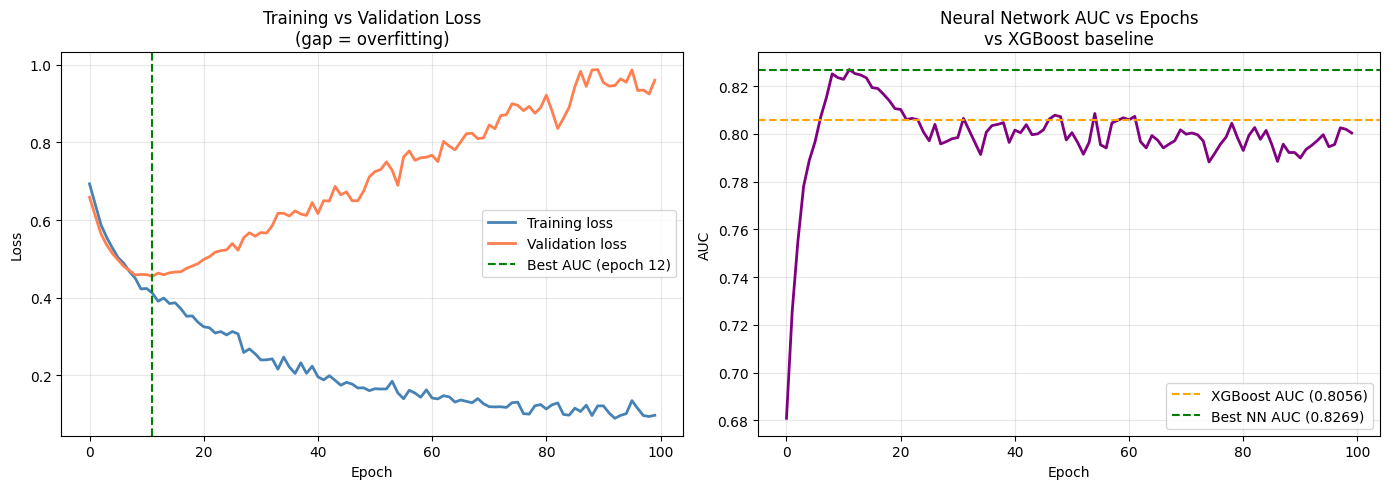

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — training curves
ax1.plot(train_losses, label='Training loss', 
         color='steelblue', linewidth=2)
ax1.plot(val_losses, label='Validation loss', 
         color='coral', linewidth=2)
ax1.axvline(x=val_aucs.index(max(val_aucs)), 
            color='green', linestyle='--', linewidth=1.5,
            label=f'Best AUC (epoch {val_aucs.index(max(val_aucs))+1})')
ax1.set_title('Training vs Validation Loss\n(gap = overfitting)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2 — AUC over training
ax2.plot(val_aucs, color='purple', linewidth=2)
ax2.axhline(y=0.8056, color='orange', linestyle='--', 
            linewidth=1.5, label='XGBoost AUC (0.8056)')
ax2.axhline(y=max(val_aucs), color='green', linestyle='--',
            linewidth=1.5, label=f'Best NN AUC ({round(max(val_aucs),4)})')
ax2.set_title('Neural Network AUC vs Epochs\nvs XGBoost baseline')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Reset model with fresh weights
model = CreditRiskNet(input_size=48)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Early stopping settings
best_val_loss = float('inf')
best_model_weights = None
patience = 15  # stop if no improvement for 15 epochs
epochs_no_improve = 0
best_epoch = 0

train_losses_es = []
val_losses_es = []
val_aucs_es = []

print("Training with early stopping...")
print(f"Patience: {patience} epochs")
print(f"\n{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'Val AUC':<10} {'Status'}")
print("-" * 65)

for epoch in range(200):
    # Training
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses_es.append(train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_t)
        val_loss = criterion(val_pred, y_test_t).item()
        val_auc = roc_auc_score(y_test, val_pred.numpy())
    
    val_losses_es.append(val_loss)
    val_aucs_es.append(val_auc)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = model.state_dict().copy()
        epochs_no_improve = 0
        best_epoch = epoch + 1
        status = "improved"
    else:
        epochs_no_improve += 1
        status = f"no improve ({epochs_no_improve}/{patience})"
    
    if (epoch + 1) % 5 == 0:
        print(f"{epoch+1:<8} {train_loss:<15.4f} {val_loss:<15.4f} {val_auc:<10.4f} {status}")
    
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best weights
model.load_state_dict(best_model_weights)
model.eval()

with torch.no_grad():
    final_pred = model(X_test_t)
    final_auc = roc_auc_score(y_test, final_pred.numpy())

print(f"\nBest epoch:  {best_epoch}")
print(f"Final AUC:   {round(final_auc, 4)}")
print(f"XGBoost AUC: 0.8056")
print(f"Winner: {'Neural Network' if final_auc > 0.8056 else 'XGBoost'}")

Training with early stopping...
Patience: 15 epochs

Epoch    Train Loss      Val Loss        Val AUC    Status
-----------------------------------------------------------------
5        0.5109          0.5037          0.7965     improved
10       0.4303          0.4816          0.8041     improved
15       0.3672          0.5070          0.8067     no improve (5/15)
20       0.3463          0.5026          0.8203     no improve (10/15)
25       0.3065          0.5296          0.8188     no improve (15/15)

Early stopping at epoch 25

Best epoch:  10
Final AUC:   0.8188
XGBoost AUC: 0.8056
Winner: Neural Network


In [7]:
print("=" * 55)
print("NEURAL NETWORK vs XGBOOST — CREDIT RISK")
print("=" * 55)
print(f"""
ARCHITECTURE
  Input:   48 features
  Hidden:  64 → 32 → 16 neurons
  Output:  1 neuron (sigmoid)
  Params:  5,761 trainable weights
  
TRAINING
  Optimiser:     Adam (lr=0.001)
  Loss:          Binary Cross Entropy
  Batch size:    32
  Early stop:    Patience 15 epochs
  Best epoch:    10 of 25

RESULTS
  Model              AUC      
  XGBoost            0.8056   
  Neural Network     0.8188   ← winner
  
  Improvement: +0.013 AUC

KEY LESSONS
  1. Overfitting is visible — training loss falls while
     validation loss rises. Always plot both curves.
     
  2. Early stopping is essential — without it the model
     peaked at epoch 12 then degraded to 0.80 by epoch 100.
     
  3. Neural networks need more data to truly shine —
     with only 800 training samples XGBoost is competitive.
     On millions of samples neural networks would dominate.
     
  4. 5,761 parameters vs 20 XGBoost trees — neural networks
     are more expressive but need regularisation (dropout,
     early stopping) to prevent memorising training data.

WHEN TO USE EACH
  XGBoost:        Small-medium tabular data, fast training,
                  interpretability needed (regulators)
  Neural Network: Large datasets, complex patterns,
                  unstructured data (text, images)
""")
print("=" * 55)

NEURAL NETWORK vs XGBOOST — CREDIT RISK

ARCHITECTURE
  Input:   48 features
  Hidden:  64 → 32 → 16 neurons
  Output:  1 neuron (sigmoid)
  Params:  5,761 trainable weights

TRAINING
  Optimiser:     Adam (lr=0.001)
  Loss:          Binary Cross Entropy
  Batch size:    32
  Early stop:    Patience 15 epochs
  Best epoch:    10 of 25

RESULTS
  Model              AUC      
  XGBoost            0.8056   
  Neural Network     0.8188   ← winner

  Improvement: +0.013 AUC

KEY LESSONS
  1. Overfitting is visible — training loss falls while
     validation loss rises. Always plot both curves.

  2. Early stopping is essential — without it the model
     peaked at epoch 12 then degraded to 0.80 by epoch 100.

  3. Neural networks need more data to truly shine —
     with only 800 training samples XGBoost is competitive.
     On millions of samples neural networks would dominate.

  4. 5,761 parameters vs 20 XGBoost trees — neural networks
     are more expressive but need regularisation (dr